In [1]:
# =========================================================
# 1. IMPORTS
# =========================================================
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import numpy as np
import pandas as pd
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

import kagglehub

2026-05-28 23:38:00.262213: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780011480.458298      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780011480.519396      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780011480.982323      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780011480.982366      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780011480.982369      58 computation_placer.cc:177] computation placer alr

In [2]:
# =========================================================
# 2. LOAD DATASET
# =========================================================
path = kagglehub.dataset_download("trnquanghuyn/casia-b")
ROOT = os.path.join(path, "output")

print("Dataset path:", ROOT)


Dataset path: /kaggle/input/datasets/trnquanghuyn/casia-b/output


In [3]:
# =========================================================
# 3. BUILD DATAFRAME
# =========================================================
IMG_SIZE = (128, 128)
MAX_SUBJECTS = 40

rows = []
subjects = sorted(os.listdir(ROOT))[:MAX_SUBJECTS]

for subject in tqdm(subjects):
    sp = os.path.join(ROOT, subject)

    if not os.path.isdir(sp):
        continue

    for cond in os.listdir(sp):
        cp = os.path.join(sp, cond)

        if not os.path.isdir(cp):
            continue

        label = cond.split("-")[0]
        if label not in ["nm", "bg", "cl"]:
            continue

        view_path = None
        for v in os.listdir(cp):
            if "090" in v:
                view_path = os.path.join(cp, v)
                break

        if view_path is None:
            continue

        for img in os.listdir(view_path):
            if img.lower().endswith((".jpg", ".png", ".bmp")):
                rows.append([os.path.join(view_path, img), label])

df = pd.DataFrame(rows, columns=["path", "label"])
print("Dataset size:", len(df))

100%|██████████| 40/40 [00:04<00:00,  8.59it/s]

Dataset size: 23916


In [4]:
# =========================================================
# 4. LABEL ENCODING
# =========================================================
label_map = {"nm": 0, "bg": 1, "cl": 2}
df["label_id"] = df["label"].map(label_map)

In [5]:
# =========================================================
# 5. LOAD + NORMALIZE IMAGES
# =========================================================
X, y = [], []

for p, l in tqdm(df[["path", "label_id"]].values):
    try:
        img = Image.open(p).convert("RGB").resize(IMG_SIZE)
        X.append(np.array(img, dtype=np.float32) / 255.0)
        y.append(l)
    except:
        continue

X = np.array(X)
y = np.array(y)

print("Final dataset:", X.shape, y.shape)


100%|██████████| 23916/23916 [03:05<00:00, 129.25it/s]


Final dataset: (23916, 128, 128, 3) (23916,)


In [6]:
# =========================================================
# 6. TRAIN / VAL / TEST SPLIT
# =========================================================
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)


In [7]:
# =========================================================
# 6A. CLASS IMBALANCE HANDLING
# =========================================================
from sklearn.utils.class_weight import compute_class_weight

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(weights))

print("Class weights:", class_weights)

Class weights: {0: np.float64(0.5540992288087909), 1: np.float64(1.6843746855820505), 2: np.float64(1.6622976864263728)}


In [8]:
# =========================================================
# 7. DATA AUGMENTATION
# =========================================================
augment = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1)
])


I0000 00:00:1780011687.958369      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [9]:
# =========================================================
# 8. CNN MODEL
# =========================================================
cnn = models.Sequential([
    layers.Input(shape=(128, 128, 3)),
    augment,

    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(3, activation='softmax')
])

cnn.compile(optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])


In [10]:
# =========================================================
# 9. TRANSFER LEARNING MODELS
# =========================================================

# MobileNetV2
base = MobileNetV2(include_top=False, input_shape=(128,128,3), weights='imagenet')
base.trainable = False

mobilenet = models.Sequential([
    layers.Input(shape=(128,128,3)),
    layers.Lambda(mobilenet_preprocess),
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(3, activation='softmax')
])

mobilenet.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

# EfficientNetB0
base2 = EfficientNetB0(include_top=False, input_shape=(128,128,3), weights='imagenet')
base2.trainable = True

effnet = models.Sequential([
    layers.Input(shape=(128,128,3)),
    layers.Lambda(effnet_preprocess),
    base2,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(3, activation='softmax')
])

effnet.compile(optimizer='adam',
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [11]:
# =========================================================
# 10. TRAINING
# =========================================================
cnn_hist = cnn.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=32,
    class_weight=class_weights
)
mob_hist = mobilenet.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=32,
    class_weight=class_weights
)

eff_hist = effnet.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=32,
    class_weight=class_weights
)

Epoch 1/5


I0000 00:00:1780011705.794760     129 cuda_dnn.cc:529] Loaded cuDNN version 91002


524/524 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.7365 - loss: 0.6596 - val_accuracy: 0.8952 - val_loss: 0.3365
Epoch 2/5
524/524 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.8400 - loss: 0.4427 - val_accuracy: 0.9058 - val_loss: 0.2584
Epoch 3/5
524/524 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.8627 - loss: 0.3762 - val_accuracy: 0.8796 - val_loss: 0.3243
Epoch 4/5
524/524 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.8740 - loss: 0.3355 - val_accuracy: 0.9024 - val_loss: 0.2577
Epoch 5/5
524/524 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.8832 - loss: 0.3056 - val_accuracy: 0.9094 - val_loss: 0.2434
Epoch 1/5


I0000 00:00:1780011762.877010     126 service.cc:152] XLA service 0x7a712c009d40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780011762.877068     126 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1780011768.762747     126 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


524/524 ━━━━━━━━━━━━━━━━━━━━ 37s 50ms/step - accuracy: 0.3548 - loss: 1.1182 - val_accuracy: 0.3842 - val_loss: 1.0809
Epoch 2/5
524/524 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.4230 - loss: 1.0681 - val_accuracy: 0.2035 - val_loss: 1.2822
Epoch 3/5
524/524 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.4636 - loss: 1.0472 - val_accuracy: 0.6763 - val_loss: 0.9223
Epoch 4/5
524/524 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.5102 - loss: 1.0094 - val_accuracy: 0.5138 - val_loss: 0.9982
Epoch 5/5
524/524 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.5457 - loss: 0.9700 - val_accuracy: 0.5548 - val_loss: 0.9391
Epoch 1/5


2026-05-28 23:44:40.158334: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-28 23:44:40.341056: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-28 23:44:40.712341: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-28 23:44:40.902123: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-28 23:44:41.187413: E external/local_xla/xla/stream_

523/524 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.8147 - loss: 0.4553

2026-05-28 23:45:42.609421: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-28 23:45:42.791189: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-28 23:45:43.132192: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-28 23:45:43.320562: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


524/524 ━━━━━━━━━━━━━━━━━━━━ 146s 142ms/step - accuracy: 0.8743 - loss: 0.3246 - val_accuracy: 0.2004 - val_loss: 1.2845
Epoch 2/5
524/524 ━━━━━━━━━━━━━━━━━━━━ 28s 53ms/step - accuracy: 0.9480 - loss: 0.1399 - val_accuracy: 0.2211 - val_loss: 1.1727
Epoch 3/5
524/524 ━━━━━━━━━━━━━━━━━━━━ 27s 52ms/step - accuracy: 0.9635 - loss: 0.1008 - val_accuracy: 0.8135 - val_loss: 0.5371
Epoch 4/5
524/524 ━━━━━━━━━━━━━━━━━━━━ 27s 52ms/step - accuracy: 0.9690 - loss: 0.0808 - val_accuracy: 0.1979 - val_loss: 2.1135
Epoch 5/5
524/524 ━━━━━━━━━━━━━━━━━━━━ 27s 51ms/step - accuracy: 0.9735 - loss: 0.0616 - val_accuracy: 0.2021 - val_loss: 1.2300


113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

 CNN
              precision    recall  f1-score   support

           0       0.96      0.92      0.94      2158
           1       0.79      0.96      0.87       710
           2       0.88      0.80      0.84       720

    accuracy                           0.90      3588
   macro avg       0.88      0.89      0.88      3588
weighted avg       0.91      0.90      0.90      3588



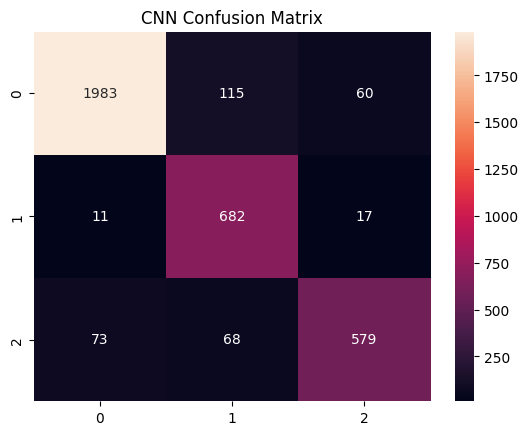

113/113 ━━━━━━━━━━━━━━━━━━━━ 14s 80ms/step

 MobileNetV2
              precision    recall  f1-score   support

           0       0.83      0.50      0.62      2158
           1       0.46      0.77      0.58       710
           2       0.32      0.49      0.38       720

    accuracy                           0.55      3588
   macro avg       0.54      0.58      0.53      3588
weighted avg       0.65      0.55      0.57      3588



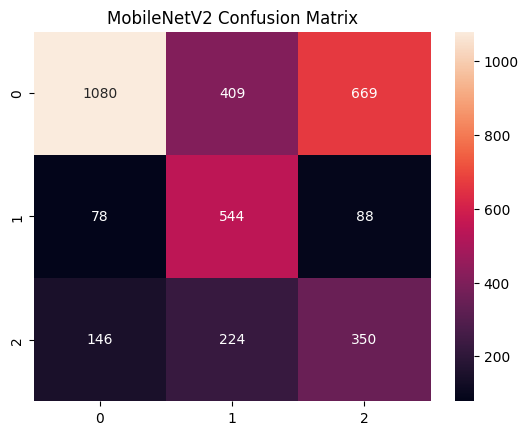

113/113 ━━━━━━━━━━━━━━━━━━━━ 15s 83ms/step

 EfficientNetB0
              precision    recall  f1-score   support

           0       0.50      0.00      0.01      2158
           1       0.00      0.00      0.00       710
           2       0.20      0.99      0.33       720

    accuracy                           0.20      3588
   macro avg       0.23      0.33      0.11      3588
weighted avg       0.34      0.20      0.07      3588



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


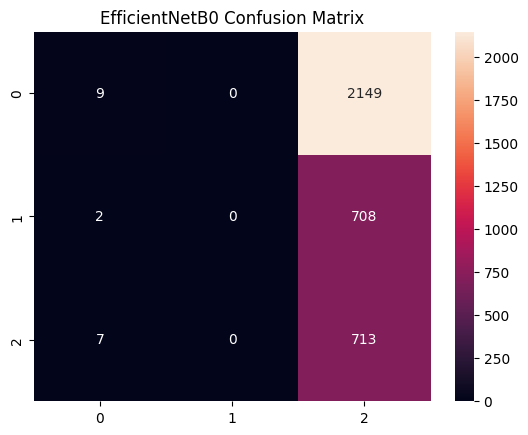

In [12]:
# =========================================================
# 11. EVALUATION FUNCTION
# =========================================================
def evaluate_model(model, X_test, y_test, name):
    preds = np.argmax(model.predict(X_test), axis=1)

    print("\n", name)
    print(classification_report(y_test, preds))

    cm = confusion_matrix(y_test, preds)

    plt.figure()
    sns.heatmap(cm, annot=True, fmt="d")
    plt.title(name + " Confusion Matrix")
    plt.savefig(f"{name}_cm.pdf")
    plt.show()

    return preds

cnn_preds = evaluate_model(cnn, X_test, y_test, "CNN")
mob_preds = evaluate_model(mobilenet, X_test, y_test, "MobileNetV2")
eff_preds = evaluate_model(effnet, X_test, y_test, "EfficientNetB0")


            Model  Accuracy
0             CNN  0.904125
1     MobileNetV2  0.550167
2  EfficientNetB0  0.201226


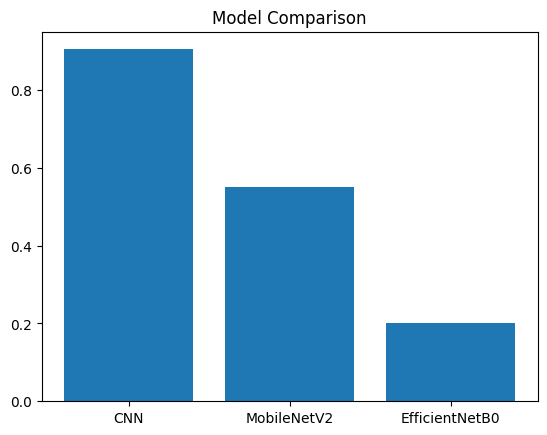

In [13]:
# =========================================================
# 12. MODEL COMPARISON TABLE
# =========================================================
models_names = ["CNN", "MobileNetV2", "EfficientNetB0"]
accs = [
    cnn.evaluate(X_test, y_test, verbose=0)[1],
    mobilenet.evaluate(X_test, y_test, verbose=0)[1],
    effnet.evaluate(X_test, y_test, verbose=0)[1]
]

comparison_df = pd.DataFrame({"Model": models_names, "Accuracy": accs})
print(comparison_df)
comparison_df.to_csv("model_comparison.csv", index=False)

plt.figure()
plt.bar(models_names, accs)
plt.title("Model Comparison")
plt.savefig("model_comparison.pdf")
plt.show()


In [14]:
import time

def benchmark(model, X, name):
    start = time.time()

    model.predict(X[:200], verbose=0)

    end = time.time()

    sec = end - start

    print(name, "Inference time:", sec)

benchmark(cnn, X_test, "CNN")
benchmark(mobilenet, X_test, "MobileNet")
benchmark(effnet, X_test, "EffNet")

CNN Inference time: 0.2576892375946045
MobileNet Inference time: 6.944664239883423
EffNet Inference time: 5.673299789428711


In [15]:
print("CNN params:", cnn.count_params())
print("MobileNet params:", mobilenet.count_params())
print("EffNet params:", effnet.count_params())

CNN params: 3305027
MobileNet params: 2422339
EffNet params: 4213926


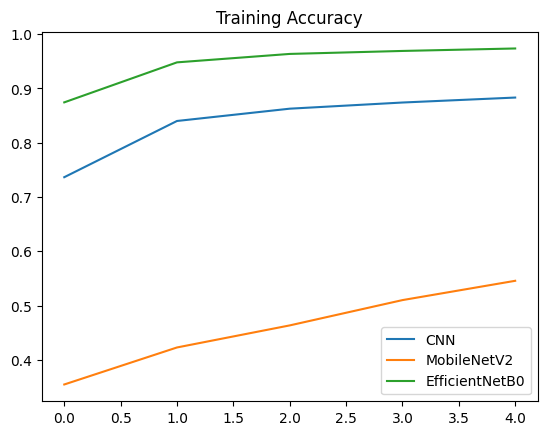

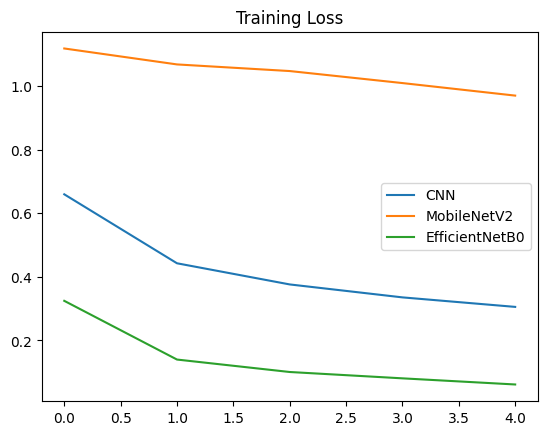

In [16]:
# =========================================================
# 13. TRAINING CURVES
# =========================================================
plt.figure()
plt.plot(cnn_hist.history['accuracy'], label="CNN")
plt.plot(mob_hist.history['accuracy'], label="MobileNetV2")
plt.plot(eff_hist.history['accuracy'], label="EfficientNetB0")
plt.legend()
plt.title("Training Accuracy")
plt.savefig("accuracy_curves.pdf")
plt.show()

plt.figure()
plt.plot(cnn_hist.history['loss'], label="CNN")
plt.plot(mob_hist.history['loss'], label="MobileNetV2")
plt.plot(eff_hist.history['loss'], label="EfficientNetB0")
plt.legend()
plt.title("Training Loss")
plt.savefig("loss_curves.pdf")
plt.show()

113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


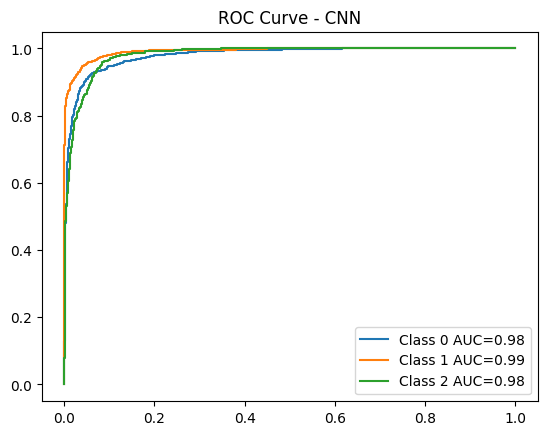

113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


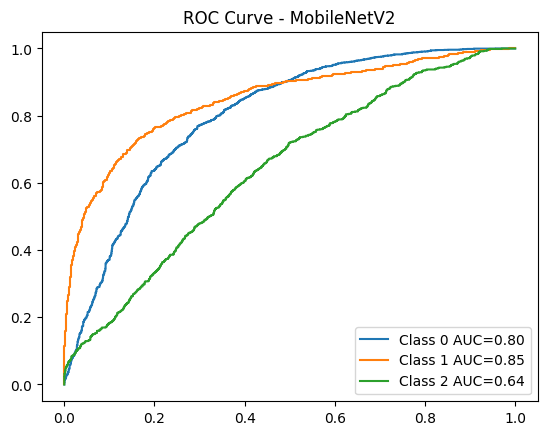

113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step


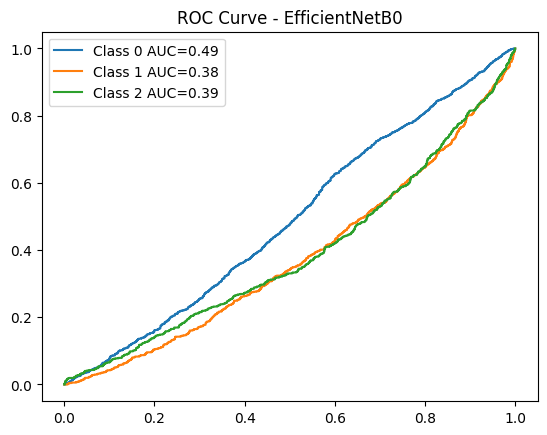

In [17]:
# =========================================================
# 14. ROC CURVE (MULTI-CLASS)
# =========================================================
y_test_bin = label_binarize(y_test, classes=[0,1,2])

def plot_roc(model, name):
    y_score = model.predict(X_test)

    plt.figure()
    for i in range(3):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"Class {i} AUC={roc_auc:.2f}")

    plt.title(f"ROC Curve - {name}")
    plt.legend()
    plt.savefig(f"{name}_roc.pdf")
    plt.show()

plot_roc(cnn, "CNN")
plot_roc(mobilenet, "MobileNetV2")
plot_roc(effnet, "EfficientNetB0")


113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Total misclassified: 344


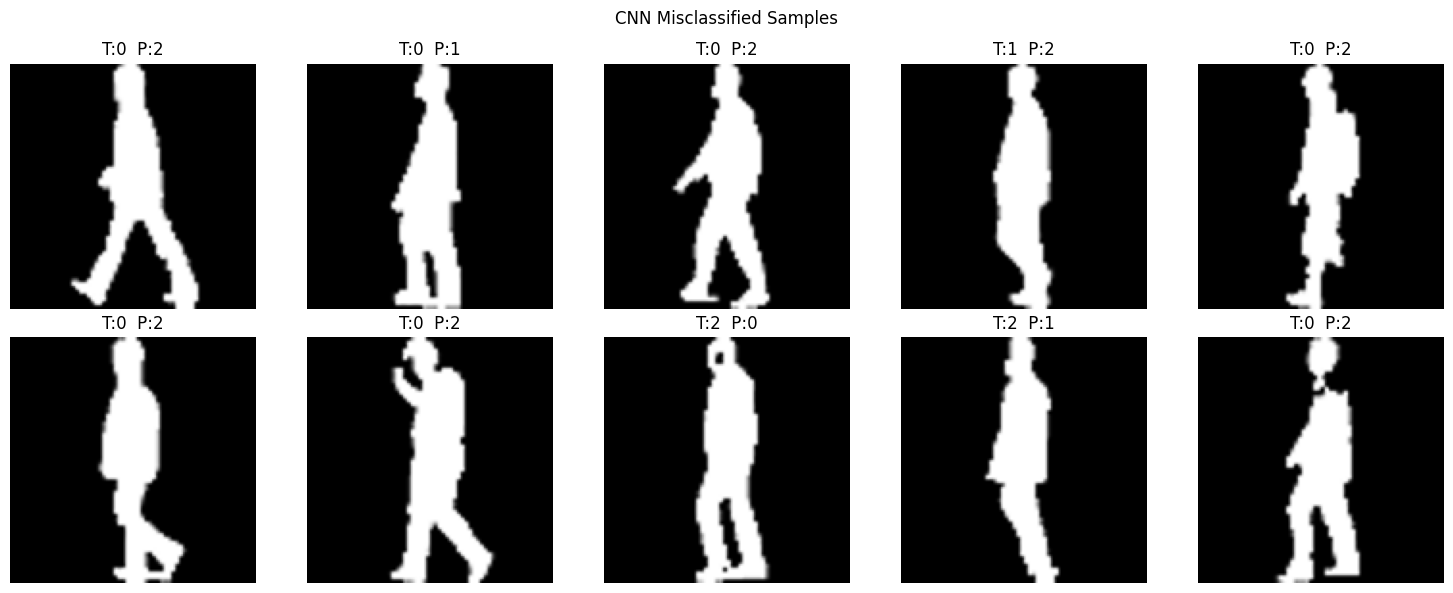

In [18]:
# =========================================================
# 15. ERROR ANALYSIS – MISCLASSIFIED SAMPLES
# =========================================================
import numpy as np
import matplotlib.pyplot as plt

# Convert prediction probabilities → class labels
cnn_preds = np.argmax(
    cnn.predict(X_test),
    axis=1
)

# If y_test is one-hot encoded
if len(y_test.shape) > 1:
    y_true = np.argmax(
        y_test,
        axis=1
    )
else:
    y_true = y_test

# Find incorrect predictions
mis_idx = np.where(
    cnn_preds != y_true
)[0]

print("Total misclassified:", len(mis_idx))

# Show first 10
plt.figure(figsize=(15,6))

for i, idx in enumerate(mis_idx[:10]):

    plt.subplot(2,5,i+1)

    plt.imshow(X_test[idx])

    plt.title(
        f"T:{y_true[idx]}  P:{cnn_preds[idx]}"
    )

    plt.axis("off")

plt.suptitle("CNN Misclassified Samples")

plt.tight_layout()

plt.savefig("error_analysis.pdf")

plt.show()

113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


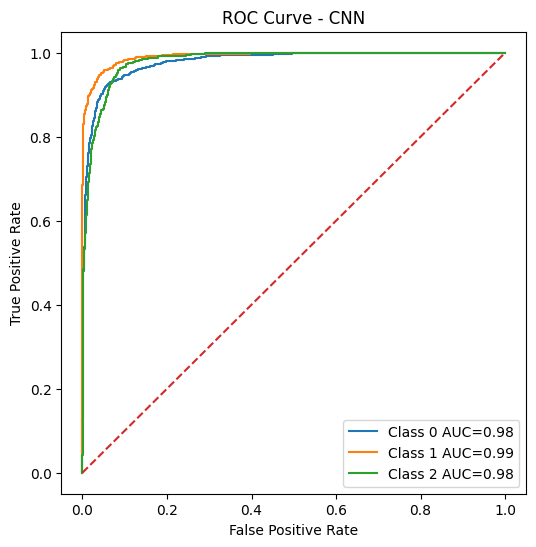

113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


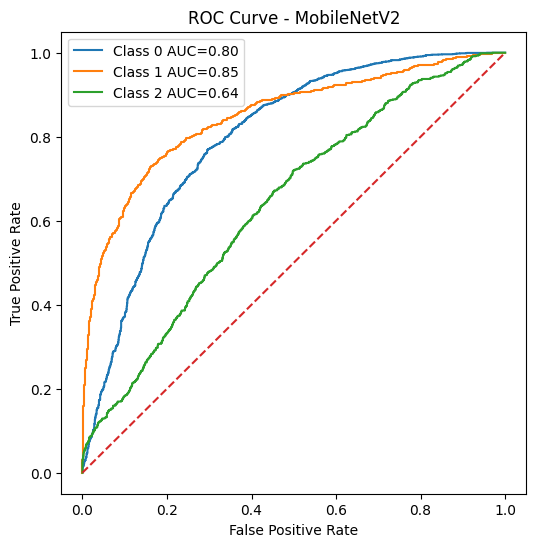

113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step


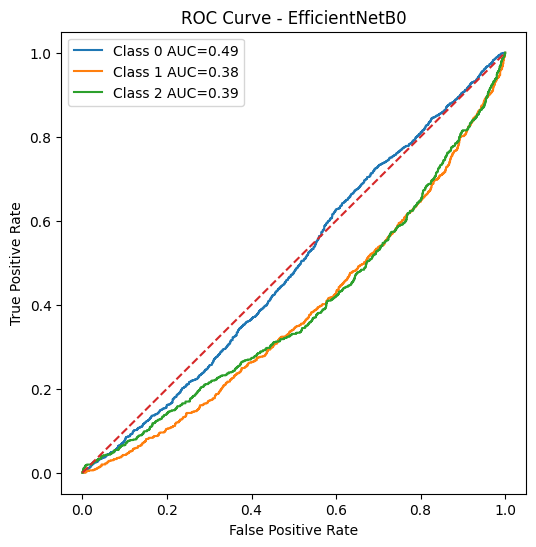

In [19]:
# =========================================================
# 14. ROC CURVE
# =========================================================
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Convert labels
if len(y_test.shape) > 1:
    y_true = np.argmax(
        y_test,
        axis=1
    )
else:
    y_true = y_test

y_test_bin = label_binarize(
    y_true,
    classes=[0,1,2]
)

def plot_roc(model, name):

    y_score = model.predict(X_test)

    plt.figure(figsize=(6,6))

    for i in range(3):

        fpr, tpr, _ = roc_curve(
            y_test_bin[:, i],
            y_score[:, i]
        )

        roc_auc = auc(
            fpr,
            tpr
        )

        plt.plot(
            fpr,
            tpr,
            label=f"Class {i} AUC={roc_auc:.2f}"
        )

    plt.plot(
        [0,1],
        [0,1],
        "--"
    )

    plt.title(
        f"ROC Curve - {name}"
    )

    plt.xlabel("False Positive Rate")

    plt.ylabel("True Positive Rate")

    plt.legend()

    plt.savefig(
        f"{name}_roc.pdf"
    )

    plt.show()


plot_roc(cnn, "CNN")
plot_roc(mobilenet, "MobileNetV2")
plot_roc(effnet, "EfficientNetB0")

In [20]:
# =========================================================
# 16. GRAD-CAM
# =========================================================
def gradcam(model, img_array, layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_array)
        loss = preds[:, np.argmax(preds[0])]

    grads = tape.gradient(loss, conv_out)
    pooled = tf.reduce_mean(grads, axis=(0,1,2))

    conv_out = conv_out[0]
    heatmap = conv_out @ pooled[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy()

In [21]:
# =========================================================
# 17. SAVE MODELS
# =========================================================
cnn.save("cnn.keras")
mobilenet.save("mobilenet.keras")
effnet.save("effnet.keras")